In [1]:
import scanpy as sc

In [2]:
adata = sc.read_h5ad("/data7/mark/STG/dataset/snRNA/merge_SCH_new/six_datasets_4v3_500_1000gene/TH_downsampled_ratio.h5ad")

In [3]:
adata.obs["celltype.L2"].value_counts()

celltype.L2
MOL-1                      23858
Astrocyte-1                21068
TH Tll1_Thsd7b Glut        19158
MOL-2                      18150
TH Tnc_Cdh20 Glut          16458
TH Car4_Tspan11 Glut       15618
TH Cald1_Gm39185 Glut      12666
TH Fam20a_Fbln1 Glut       12130
TH Kcnk13_Nox4 Glut         8049
OPC                         7460
TH Ccdc192_Gli3 Glut        7451
TH Meis2_Gm2115 GABA        6763
TH Fgf10_Gm16263 Glut       4859
TH Parm1_Mdga1 Glut         4618
MOL-3                       4239
TH Egflam_Fbn2 Glut         3528
TH Tac2_Pde11a Glut         2643
Astrocyte-3                 2281
TH Col27a1_Npsr1 Glut       2077
MFOL                        2015
Astrocyte-4                 1299
Microglia-1                 1095
COP                          909
Endothelial cell             702
Choroid plexus cell          590
Ependymal cell               589
Microglia-2                  584
VLMC                         308
NFOL                         180
Pericyte                     15

In [4]:
#adata_subset = adata[adata.obs["celltype.L2"].isin(["TH Tll1_Thsd7b Glut"])]
# Select the second most abundant cell type
adata_subset = adata[adata.obs["celltype.L2"].isin(adata.obs["celltype.L2"].value_counts().head(2).index[1:2])]
# Keep only male
adata_subset = adata_subset[adata_subset.obs["sex"] == "M"]
# Remove samples whose name contains MW22B
#adata_subset = adata_subset[~adata_subset.obs["sample"].str.contains("MW22B")]

In [5]:
# Explore the subset data structure
print(f"adata_subset shape: {adata_subset.shape}")
print(f"Obs columns: {list(adata_subset.obs.columns)}")
print(f"X type: {type(adata_subset.X)}")
print(f"X min/max: {adata_subset.X.min():.4f} / {adata_subset.X.max():.4f}")
print(f"Number of cells: {adata_subset.n_obs}")
print(f"Number of genes: {adata_subset.n_vars}")
print()
# Check grouping information
print("celltype.L2 value counts:")
print(adata_subset.obs["celltype.L2"].value_counts())
print()
# Check for batch information
for col in adata_subset.obs.columns:
    if "batch" in col.lower():
        print(f"Batch column: {col}")
        print(adata_subset.obs[col].value_counts())

adata_subset shape: (13885, 16428)
Obs columns: ['sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'scrublet_score', 'predicted_doublets', 'scrublet_leiden', 'cluster_scrublet_score', 'doublet_pval', 'doublet_bh_pval', 'date', 'status', 'sex', 'donor', 'region', 'company', 'cells_number', 'fraction_reads', 'mean_reads', 'median_umi', 'median_genes', 'total_genes', 'mapped_genome', 'mapped_confidently_genome', 'mapped_intergenic', 'mapped_intronic', 'mapped_exonic', 'mapped_transcriptome', 'antisense_gene', 'reads_number', 'valid_barcodes', 'sequencing_saturation', 'q30_barcode', 'q30_rna', 'q30_umi', 'tech', 'batch', 'predicted_labels

In [6]:
# Check columns that can be used for grouping
for col in ["status", "region", "sex", "donor", "date"]:
    if col in adata_subset.obs.columns:
        print(f"\n{col} value counts:")
        print(adata_subset.obs[col].value_counts().head(20))


status value counts:
status
CSRES    3407
CUSUS    3049
CSSUS    2948
CON      2317
CURES    2164
Name: count, dtype: int64

region value counts:
region
TH    13885
Name: count, dtype: int64

sex value counts:
sex
M    13885
Name: count, dtype: int64

donor value counts:
donor
MC25B       1748
CSRS1-3     1206
CS2-1       1201
CSRS9-1     1109
CSRS10-3    1092
CS1-1       1033
MW45A        964
MC50E        917
MC52B        795
CS7-3        714
MC48D        549
MW22B        533
MW47A        522
MC50B        469
MC46D        452
MW51A        298
MC52E        283
Name: count, dtype: int64

date value counts:
date
20250728    3407
20250411    2948
20250309    2164
20250102    2094
20241029    1748
20250107     991
20241024     533
Name: count, dtype: int64


In [7]:
# Check whether adata has raw or layers
print("Has raw:", adata.raw is not None)
if hasattr(adata, 'layers'):
    print("Layers keys:", list(adata.layers.keys()))
print("adata_subset.X shape:", adata_subset.X.shape)
print("adata_subset.X type:", type(adata_subset.X))

# Check whether var has gene names
print("\nvar columns:", list(adata_subset.var.columns[:20]))
print("var index head:", adata_subset.var.index[:5].tolist())

Has raw: False
Layers keys: ['counts', None]
adata_subset.X shape: (13885, 16428)
adata_subset.X type: <class 'anndata._core.views.SparseCSRMatrixView'>

var columns: ['gene_ids']
var index head: ['Xkr4', 'Gm1992', 'Gm19938', 'Rp1', 'Mrpl15']


In [8]:
import sys
sys.path.insert(0, "/home/junyichen/code/RUVAEDEG")
from model import RUVVAE_DEG, ZINBLoss, compute_deg, compute_deg_all_methods_legacy

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
batch_key = "company"
group_key = "status"
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# DEG test mode: "wald" (default, closest to the DESeq2 Wald idea),
# "welch", "permutation", "bayes" or "all".
DEG_METHOD = "welch"

In [9]:
hkg_priority = [
    "Aars", "Sars",
    "Polr2a", "Polr2f",
    "Psmd6", "Psmd7", "Psma5",
    "Rer1", "Ipo8", "Pop4", "Pes1",
    "Oaz1",
    "Rpl13a", "Rpl27", "Rps13", "Rps20",
    "Hprt1", "Gusb", "Ppia", "Ywhaz"
]

candidate_negative_control_genes = [
    # Relatively stable across large-scale cross-tissue analyses
    "Oaz1",
    "Rps13",
    "Rps20",
    "Rpl27",

    # Housekeeping genes reported as relatively stable in mouse brain
    "Aars",
    "Polr2f",
    "Psmd6",
    "Psmd7",
    "Psma5",

    # RNA processing, nucleocytoplasmic transport and basic cell maintenance
    "Ipo8",
    "Pop4",
    "Pes1",
    "Rer1",

    # Can be used as additional candidates, but must be validated in this data
    "Rpl13a",
    "Cyc1",
    "Sdha",
    "Ubc"
]

hkg_priority = candidate_negative_control_genes 

In [10]:
# ========== 1. Prepare data (all genes) [ZINB mode: use raw counts as input] ==========
adata_hvg = adata_subset.copy()

# Clean inf/nan from the data
X_data = adata_hvg.X.toarray() if hasattr(adata_hvg.X, 'toarray') else adata_hvg.X.copy()
X_data = np.nan_to_num(X_data, nan=0.0, posinf=0.0, neginf=0.0)
adata_hvg.X = X_data

# Normalizing to median total counts
sc.pp.normalize_total(adata_hvg)
# Logarithmize the data (for DEG analyses such as logFC)
sc.pp.log1p(adata_hvg)

# Use all genes (no HVG filtering)
n_genes_total = adata_hvg.n_vars
Y_all = X_data  # (n_cells, n_genes)
gene_names = adata_hvg.var.index.tolist()
print(f"Total number of genes: {n_genes_total}")
print(f"Expression matrix shape: {Y_all.shape}")
print(f"Expression matrix range: {Y_all.min():.4f} ~ {Y_all.max():.4f}")

# Group labels
group_labels = adata_hvg.obs[group_key].values
groups_unique = sorted(np.unique(group_labels).tolist())
print(f"Groups: {groups_unique}")
print(f"CON: {(group_labels==groups_unique[0]).sum()}, CSDS: {(group_labels==groups_unique[1]).sum()}")

# Batch labels
batch_labels = adata_hvg.obs[batch_key].values
batches_unique = sorted(np.unique(batch_labels).tolist())
print(f"Number of batches: {len(batches_unique)}")
print(f"Batches: {batches_unique}")

Total number of genes: 16428
Expression matrix shape: (13885, 16428)
Expression matrix range: 0.0000 ~ 7.1050
Groups: ['CON', 'CSRES', 'CSSUS', 'CURES', 'CUSUS']
CON: 2317, CSDS: 3407
Number of batches: 3
Batches: ['beirui', 'seekgene', 'yunzhun']


In [11]:
# ========== 1b. Compute n_genes_on (number of detected genes per cell, used as a continuous covariate) ==========
# Compute the number of genes with expression > 0 per cell from raw counts.
x_raw = adata_hvg.layers["counts"].toarray() if hasattr(adata_hvg.layers["counts"], "toarray") else adata_hvg.layers["counts"]
x_raw = np.nan_to_num(x_raw, nan=0.0, posinf=0.0, neginf=0.0)
n_genes_on_raw = (x_raw > 0).sum(axis=1).astype(np.float32)

# Continuous covariates must be standardized, otherwise W_cov becomes unstable due to large scale.
n_genes_on_mean = float(n_genes_on_raw.mean())
n_genes_on_std = float(n_genes_on_raw.std())
if n_genes_on_std < 1e-8:
    raise ValueError("n_genes_on has insufficient variation to be used as a continuous covariate")
n_genes_on = ((n_genes_on_raw - n_genes_on_mean) / n_genes_on_std).astype(np.float32)
adata_hvg.obs["n_genes_on"] = n_genes_on
print(f"n_genes_on source: raw counts > 0")
print(f"raw mean/std: {n_genes_on_mean:.1f} / {n_genes_on_std:.1f}")
print(f"standardized range: {n_genes_on.min():.3f} ~ {n_genes_on.max():.3f}")

n_genes_on source: raw counts > 0
raw mean/std: 1537.8 / 451.2
standardized range: -1.996 ~ 5.570


In [12]:
# ========== 2. Select negative control genes (HKG literature pool + data-driven) ==========

# ---------- User option: NC selection strategy ----------
NC_MODE = "data_only"  # options: "data_only", "hkg_only", "hybrid"

# ---------- 2a. Define HKG candidate function (adapted to mouse gene names) ----------
import re

def build_candidate_nc_genes_mouse(gene_names):
    """Build the candidate negative-control gene pool (adapted to mouse gene symbol casing)."""
    
    # 1) Literature-curated housekeeping genes (Eisenberg & Levanon 2013, converted to mouse casing)
    eisenberg_hkg = {
        "Actb", "B2m", "Gapdh", "Hmbs", "Hprt1", "Pgk1", "Ppia",
        "Rpl13a", "Rplp0", "Sdha", "Tbp", "Tfrc", "Ubc", "Vcp",
        "Ywhaz", "C1orf43", "Chmp2a", "Emc7", "Gpi", "Psmb2",
        "Psmb4", "Rab7a", "Reep5", "Snrpd3", "Vps29",
        "Cltc", "Csnk2b", "Ddx5", "Eef1a1", "Eif4a2",
        "Hnrnpk", "Nono", "Rpl32", "Rps18", "Sf3b1",
        "Srsf3", "Sumo1", "Ube2d2", "Usp22", "Xrn2",
    }
    
    # 2) Ribosomal proteins (cytoplasmic + mitochondrial)
    rp_genes = {g for g in gene_names 
                if re.match(r'^(RP[SL]|Mrp[sl]|Rps|Rpl)[0-9]', g, re.IGNORECASE)}
    
    # 3) Translation elongation factors
    eef_genes = {g for g in gene_names if re.match(r'^(Eef[12]|EIF)', g, re.IGNORECASE)}
    
    # 4) Proteasome subunits
    psm_genes = {g for g in gene_names if re.match(r'^(Psm|PSM)[A-Da-d][0-9]', g)}
    
    # 5) Mitochondrial ribosomal proteins
    mrp_genes = {g for g in gene_names if re.match(r'^Mrp[sl][0-9]', g, re.IGNORECASE)}
    
    candidate = (eisenberg_hkg & set(gene_names)) | rp_genes | eef_genes | psm_genes | mrp_genes
    return np.array([g in candidate for g in gene_names])


# ---------- 2b. Compute the expression matrix ----------
counts = adata_hvg.layers["counts"].toarray()
counts = np.nan_to_num(counts, nan=0.0, posinf=0.0, neginf=0.0)
Y_log = np.log1p(counts)

# Compute group means by status
mask_con = group_labels == groups_unique[0]
mask_csds = group_labels == groups_unique[1]
mean_con = Y_log[mask_con].mean(0)
mean_csds = Y_log[mask_csds].mean(0)
fc_abs = np.abs(mean_csds - mean_con)  # absolute logFC between the two groups

# ---------- 2c. Build HKG + priority list ----------
hkg_mask = build_candidate_nc_genes_mouse(gene_names)
print(f"HKG candidate genes (literature + ribosomal + proteasome etc.): {hkg_mask.sum()}")

# User-defined priority HKG list (ensure they are always in the negative controls)
priority_mask = np.zeros(n_genes_total, dtype=bool)
for hkg in hkg_priority:
    if hkg in gene_names:
        idx = gene_names.index(hkg)
        priority_mask[idx] = True
print(f"Priority HKG list hits: {priority_mask.sum()} / {len(hkg_priority)}")

# Total HKG pool = literature candidates + priority list
hkg_combined_mask = hkg_mask | priority_mask

# ---------- 2d. Select negative control genes according to NC_MODE ----------
n_nc_total = 500  # total number of negative control genes

if NC_MODE == "data_only":
    # Purely data-driven: pick the n_nc_total genes with the smallest logFC from all genes
    nc_idx = np.argsort(fc_abs)[:n_nc_total]
    print(f"[mode: data_only] Picked {n_nc_total} genes with smallest |logFC| from all {n_genes_total} genes")

elif NC_MODE == "hkg_only":
    # Purely prior knowledge: use only the HKG literature pool + priority list
    available_hkg_idx = np.where(hkg_combined_mask)[0]
    if len(available_hkg_idx) >= n_nc_total:
        # More HKG than target: pick the ones with the smallest |logFC|
        hkg_fc = fc_abs.copy()
        hkg_fc[~hkg_combined_mask] = np.inf
        nc_idx = np.argsort(hkg_fc)[:n_nc_total]
        print(f"[mode: hkg_only] Picked {n_nc_total} from the HKG pool ({len(available_hkg_idx)})")
    else:
        # Not enough HKG: use all of them
        nc_idx = available_hkg_idx
        print(f"[mode: hkg_only] Only {len(available_hkg_idx)} HKG available, using all")

elif NC_MODE == "hybrid":
    # Hybrid: prior HKG + data-driven fill-in
    n_hkg = hkg_combined_mask.sum()
    if n_hkg >= n_nc_total:
        hkg_fc = fc_abs.copy()
        hkg_fc[~hkg_combined_mask] = np.inf
        nc_idx = np.argsort(hkg_fc)[:n_nc_total]
        print(f"[mode: hybrid] HKG={n_hkg} >= {n_nc_total}, picked the smallest |logFC| from HKG")
    else:
        remaining = n_nc_total - n_hkg
        non_hkg_fc = fc_abs.copy()
        non_hkg_fc[hkg_combined_mask] = np.inf
        data_idx = np.argsort(non_hkg_fc)[:remaining]
        nc_idx = np.concatenate([np.where(hkg_combined_mask)[0], data_idx])
        print(f"[mode: hybrid] Kept all HKG={n_hkg} + data-driven fill of {remaining}")
else:
    raise ValueError(f"NC_MODE = {NC_MODE} not supported; use 'data_only' / 'hkg_only' / 'hybrid'")

neg_control_mask = np.zeros(n_genes_total, dtype=bool)
neg_control_mask[nc_idx] = True

# ---------- 2e. Print detailed statistics ----------
nc_hkg_overlap = neg_control_mask & hkg_combined_mask
nc_priority_overlap = neg_control_mask & priority_mask
print(f"\nFinal negative control genes: {neg_control_mask.sum()}")
print(f"  of which HKG literature candidates: {nc_hkg_overlap.sum()}")
print(f"  of which priority HKG list: {nc_priority_overlap.sum()}")
print(f"  of which non-HKG (hybrid mode only): {neg_control_mask.sum() - nc_hkg_overlap.sum()}")
print(f"\nNegative control genes (first 10): {[gene_names[i] for i in nc_idx[:10]]}")
print(f"Negative control gene logFC range: {fc_abs[nc_idx].min():.4f} ~ {fc_abs[nc_idx].max():.4f}")

HKG candidate genes (literature + ribosomal + proteasome etc.): 301
Priority HKG list hits: 17 / 17
[mode: data_only] Picked 500 genes with smallest |logFC| from all 16428 genes

Final negative control genes: 500
  of which HKG literature candidates: 3
  of which priority HKG list: 0
  of which non-HKG (hybrid mode only): 497

Negative control genes (first 10): ['Gm45591', 'Gm42744', 'Gm12068', 'Gm28319', 'Gm5095', 'Zbbx', 'Krt77', 'Gm26974', 'Atcayos', 'Gm11750']
Negative control gene logFC range: 0.0000 ~ 0.0002


## 13. New model test: SCVIWithDiseaseEffect (inherits scVI, reconstruction split into scVI part x disease-group linear effect)

In [13]:
# ========== 13a. Import the new model + prepare scVI-format data ==========
import sys
sys.path.insert(0, "/home/junyichen/code/RUVAEDEG")
from model_scvi_disease import SCVIWithDiseaseEffect, VAEWithDiseaseEffect

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy.sparse import csr_matrix

# Use the same data subset as the RUVVAE above, but register it via scVI's setup_anndata
# Note: scVI requires raw counts in X or a layer (ZINB uses counts)
adata_scvi = adata_subset.copy()

# Ensure X is raw counts (scVI ZINB needs counts, not log1p)
if "counts" in adata_scvi.layers:
    adata_scvi.X = adata_scvi.layers["counts"].copy()
else:
    # If there is no counts layer, use the current X (assumed to be counts)
    pass

# Clean inf/nan
X_scvi = adata_scvi.X.toarray() if hasattr(adata_scvi.X, "toarray") else adata_scvi.X.copy()
X_scvi = np.nan_to_num(X_scvi, nan=0.0, posinf=0.0, neginf=0.0)
adata_scvi.X = csr_matrix(X_scvi.astype(np.float32))

# Compute n_genes_on (continuous covariate, consistent with RUVVAE)
x_raw = X_scvi
n_genes_on_raw = (x_raw > 0).sum(axis=1).astype(np.float32)
n_genes_on_mean = float(n_genes_on_raw.mean())
n_genes_on_std = float(n_genes_on_raw.std())
n_genes_on_scvi = ((n_genes_on_raw - n_genes_on_mean) / n_genes_on_std).astype(np.float32)
adata_scvi.obs["n_genes_on"] = n_genes_on_scvi

print(f"adata_scvi shape: {adata_scvi.shape}")
print(f"X dtype: {adata_scvi.X.dtype}, range: [{adata_scvi.X.min()}, {adata_scvi.X.max()}]")
print(f"status groups: {adata_scvi.obs[group_key].value_counts().to_dict()}")
print(f"batch groups: {adata_scvi.obs[batch_key].value_counts().to_dict()}")

/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


adata_scvi shape: (13885, 16428)
X dtype: float32, range: [0.0, 1900.0]
status groups: {'CSRES': 3407, 'CUSUS': 3049, 'CSSUS': 2948, 'CON': 2317, 'CURES': 2164}
batch groups: {'beirui': 10613, 'yunzhun': 2281, 'seekgene': 991}


In [14]:
# ========== 13b. setup_anndata + instantiation + forward validation ==========
torch.manual_seed(seed)
np.random.seed(seed)

# Register: batch_key for technical batches, labels_key for disease groups (linear effect)
SCVIWithDiseaseEffect.setup_anndata(
    adata_scvi,
    batch_key=batch_key,          # "company"
    labels_key=group_key,         # "status" -> disease-group linear effect
    continuous_covariate_keys=["n_genes_on"],
)

model_disease = SCVIWithDiseaseEffect(
    adata_scvi,
    n_latent=32,
    n_layers=2,
    gene_likelihood="zinb",
    group_effect_scale=0.01,      # W_group init std
    group_effect_prior=0.0,       # L2 penalty weight (0 = no penalty)
)

print(f"Module type: {type(model_disease.module).__name__}")
print(f"W_group shape (n_labels, n_genes): {tuple(model_disease.module.W_group.shape)}")
print(f"Number of labels (status) categories: {model_disease.module.n_labels}")
print(f"Number of batches: {model_disease.module.n_batch}")

# ---- Forward validation: reconstruction split mu = mu_scvi * mu_disease ----
scdl = model_disease._make_data_loader(adata=adata_scvi, batch_size=256)
for tensors in scdl:
    inf, gen, loss = model_disease.module.forward(tensors, compute_loss=True)
    px = gen["px"]
    print(f"\npx.mu shape: {tuple(px.mu.shape)}")
    print(f"mu_scvi shape: {tuple(gen['mu_scvi'].shape)}")
    print(f"mu_disease shape: {tuple(gen['mu_disease'].shape)}")
    print(f"group_effect shape: {tuple(gen['group_effect'].shape)}")
    print(f"loss: {float(loss.loss):.4f}")

    # Key assertion: combined mean == scVI part x disease part
    torch.testing.assert_close(
        px.mu, gen["mu_scvi"] * gen["mu_disease"], rtol=1e-4, atol=1e-4
    )
    print("✓ Reconstruction split validated: mu == mu_scvi * mu_disease")

    # Disease effect should be positive (exp form)
    assert (gen["mu_disease"] > 0).all()
    print(f"✓ mu_disease > 0 (exp form), range: [{gen['mu_disease'].min():.4f}, {gen['mu_disease'].max():.4f}]")
    break

Module type: VAEWithDiseaseEffect
W_group shape (n_labels, n_genes): (5, 16428)
Number of labels (status) categories: 5
Number of batches: 3


/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/torch/utils/data/_utils/collate.py:70: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return torch.as_tensor(data)



px.mu shape: (256, 16428)
mu_scvi shape: (256, 16428)
mu_disease shape: (256, 16428)
group_effect shape: (256, 16428)
loss: 5926.8828
✓ Reconstruction split validated: mu == mu_scvi * mu_disease
✓ mu_disease > 0 (exp form), range: [0.9619, 1.0415]


/tmp/ipykernel_21480/1183937386.py:36: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  print(f"loss: {float(loss.loss):.4f}")


In [15]:
# ========== 13c. Training + reconstruction split + multi-disease effects ==========
# Short training (for demonstration; increase max_epochs for real use)
model_disease.train(
    max_epochs=100,
    train_size=0.9,
    batch_size=256,
    early_stopping=True,
    early_stopping_patience=5,
    plan_kwargs={"lr": 1e-3},
)
print("Training complete")

# ---- Two reconstruction parts ----
mu_scvi, mu_disease = model_disease.get_reconstruction_parts(adata=adata_scvi, batch_size=256)
print(f"\nmu_scvi shape: {mu_scvi.shape}")
print(f"mu_disease shape: {mu_disease.shape}")
print(f"mu_scvi range: [{mu_scvi.min():.2f}, {mu_scvi.max():.2f}]")
print(f"mu_disease range: [{mu_disease.min():.4f}, {mu_disease.max():.4f}]")

# ---- Combined reconstruction ----
recon = model_disease.get_reconstruction(adata=adata_scvi, batch_size=256)
print(f"recon (mu_scvi * mu_disease) shape: {recon.shape}")
print(f"recon range: [{recon.min():.2f}, {recon.max():.2f}]")

# ---- Per-disease logFC relative to the control group ----
CONTROL_GROUP = "CON"
df_lfc_by_group = model_disease.get_disease_logfc_by_group(
    control_group=CONTROL_GROUP
)
logfc_columns = [c for c in df_lfc_by_group.columns if c.startswith("logFC_")]
print(f"\nDisease groups compared with control: {logfc_columns}")
for column in logfc_columns:
    values = df_lfc_by_group[column].to_numpy()
    print(f"{column}: range=[{values.min():.4f}, {values.max():.4f}], "
          f"mean_abs={np.abs(values).mean():.4f}")

# Show the top genes for each disease contrast
for column in logfc_columns:
    top_group = (
        df_lfc_by_group[["gene", column]]
        .assign(abs_lfc=lambda frame: np.abs(frame[column]))
        .sort_values("abs_lfc", ascending=False)
        .head(10)
    )
    print(f"\nTop 10 genes for {column}:")
    display(top_group)

Trainer will use only 1 of 8 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=8)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA A800 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4

Epoch 92/100:  92%|█████████▏| 92/100 [00:52<00:04,  1.75it/s, v_num=1, train_loss=4.68e+3]
Monitored metric elbo_validation did not improve in the last 5 records. Best score: 4813.269. Signaling Trainer to stop.
Training complete

mu_scvi shape: (13885, 16428)
mu_disease shape: (13885, 16428)
mu_scvi range: [0.00, 1891.43]
mu_disease range: [0.4473, 2.0651]
recon (mu_scvi * mu_disease) shape: (13885, 16428)
recon range: [0.00, 2029.53]

Disease groups compared with control: ['logFC_CON_vs_CON', 'logFC_CSRES_vs_CON', 'logFC_CSSUS_vs_CON', 'logFC_CURES_vs_CON', 'logFC_CUSUS_vs_CON']
logFC_CON_vs_CON: range=[0.0000, 0.0000], mean_abs=0.0000
logFC_CSRES_vs_CON: range=[-1.3790, 1.1695], mean_abs=0.1077
logFC_CSSUS_vs_CON: range=[-0.7784, 0.7907], mean_abs=0.1047
logFC_CURES_vs_CON: range=[-1.1820, 0.9142], mean_abs=0.1166
logFC_CUSUS_vs_CON: range=[-0.6622, 0.6168], mean_abs=0.1016

Top 10 genes for logFC_CON_vs_CON:


,gene,logFC_CON_vs_CON,abs_lfc
0,Xkr4,0.0,0.0
1,Gm1992,0.0,0.0
2,Gm19938,0.0,0.0
3,Rp1,0.0,0.0
4,Mrpl15,0.0,0.0
5,Lypla1,0.0,0.0
6,Tcea1,0.0,0.0
7,Rgs20,0.0,0.0
8,Atp6v1h,0.0,0.0
9,Oprk1,0.0,0.0



Top 10 genes for logFC_CSRES_vs_CON:


,gene,logFC_CSRES_vs_CON,abs_lfc
1876,9630028H03Rik,-1.379001,1.379001
3846,Rsrp1,1.169492,1.169492
14544,Gm42418,1.004961,1.004961
13913,Cmss1,0.874965,0.874965
10810,Ddx5,0.871392,0.871392
1019,Camk1d,0.776729,0.776729
6447,Dbp,0.733777,0.733777
8973,Lars2,0.729695,0.729695
8322,Zbtb16,-0.728788,0.728788
12845,Gm10076,0.724014,0.724014


...

,gene,logFC_CSSUS_vs_CON,abs_lfc
8757,Abhd14b,0.790674,0.790674
3846,Rsrp1,0.786944,0.786944
8322,Zbtb16,-0.778432,0.778432
14338,Fkbp5,-0.761708,0.761708
9164,Smpd2,0.707598,0.707598
1582,4930445B16Rik,-0.650677,0.650677
3183,Gm11867,-0.628429,0.628429
12753,Hr,-0.626258,0.626258
2572,Bcan,0.598142,0.598142
6447,Dbp,0.588066,0.588066



Top 10 genes for logFC_CURES_vs_CON:


,gene,logFC_CURES_vs_CON,abs_lfc
8322,Zbtb16,-1.181985,1.181985
8757,Abhd14b,0.914224,0.914224
14338,Fkbp5,-0.898781,0.898781
15198,Smim3,-0.842484,0.842484
3846,Rsrp1,0.840826,0.840826
3412,Megf9,-0.823568,0.823568
14543,Gm26917,-0.815865,0.815865
15475,Gm14964,0.804933,0.804933
13781,Nrros,-0.790043,0.790043
2586,Paqr6,0.778808,0.778808



Top 10 genes for logFC_CUSUS_vs_CON:


,gene,logFC_CUSUS_vs_CON,abs_lfc
1876,9630028H03Rik,-0.662218,0.662218
14093,Pde10a,-0.619670,0.619670
6447,Dbp,0.616808,0.616808
12197,Cartpt,0.594630,0.594630
139,Tbc1d8,-0.585076,0.585076
1121,Dpp7,0.581783,0.581783
13219,Cdc42ep1,0.568039,0.568039
3670,Gm12925,-0.563269,0.563269
4762,Aldh2,0.549502,0.549502
3183,Gm11867,-0.544556,0.544556


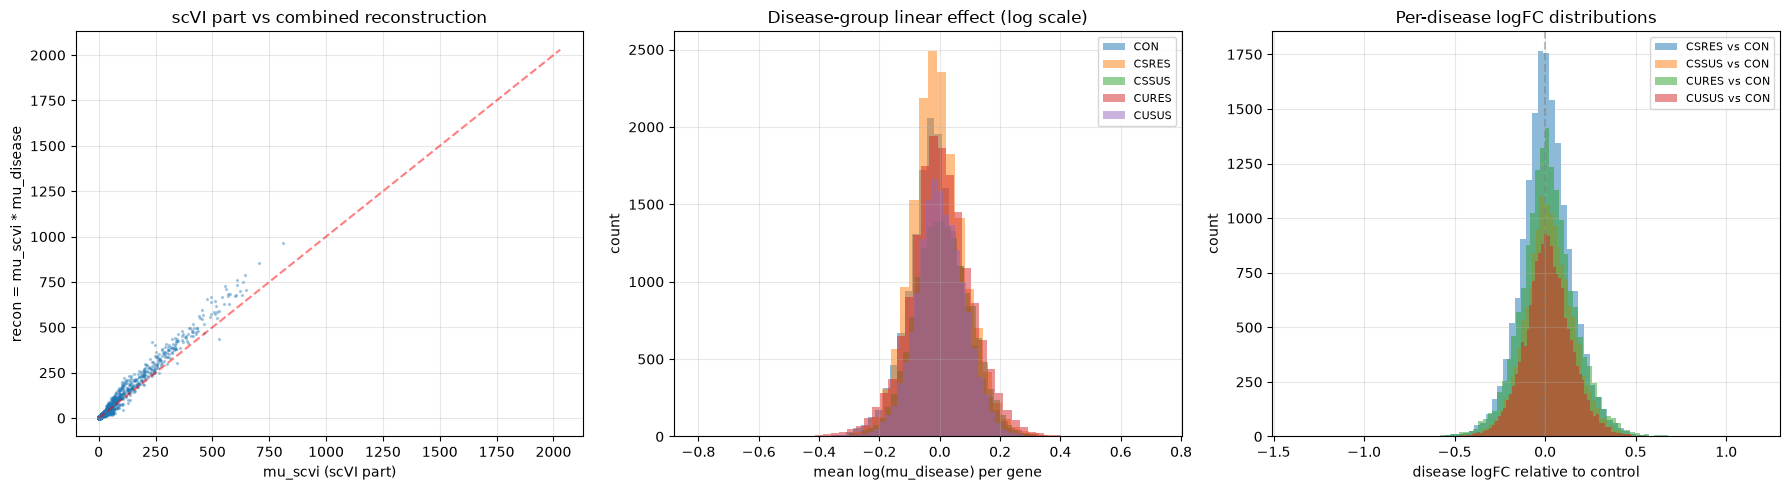

=== Multi-disease SCVIWithDiseaseEffect test complete ===
✓ One W_group row is learned for each disease label
✓ Each disease effect is reported relative to CONTROL_GROUP
✓ Reconstruction remains mu_scvi * mu_disease


In [16]:
# ========== 13d. Visualization: reconstruction split + per-disease effects ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) scVI part vs combined reconstruction
ax = axes[0]
idx_plot = np.random.choice(mu_scvi.shape[0], min(300, mu_scvi.shape[0]), replace=False)
ax.scatter(mu_scvi[idx_plot, :].ravel(), recon[idx_plot, :].ravel(), s=2, alpha=0.3)
ax.plot([0, recon.max()], [0, recon.max()], "r--", alpha=0.5)
ax.set_xlabel("mu_scvi (scVI part)")
ax.set_ylabel("recon = mu_scvi * mu_disease")
ax.set_title("scVI part vs combined reconstruction")
ax.grid(True, alpha=0.3)

# 2) Disease effect distribution by status
ax = axes[1]
status_labels = adata_scvi.obs[group_key].values
for disease_group in sorted(np.unique(status_labels)):
    mask = status_labels == disease_group
    ax.hist(np.log(mu_disease[mask]).mean(0), bins=50, alpha=0.5, label=disease_group)
ax.set_xlabel("mean log(mu_disease) per gene")
ax.set_ylabel("count")
ax.set_title("Disease-group linear effect (log scale)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3) Per-disease logFC distributions relative to control
ax = axes[2]
for column in logfc_columns:
    disease_name = column.removeprefix("logFC_").split("_vs_")[0]
    if disease_name == CONTROL_GROUP:
        continue
    ax.hist(
        df_lfc_by_group[column], bins=80, alpha=0.5,
        label=f"{disease_name} vs {CONTROL_GROUP}",
    )
ax.axvline(0, c="gray", ls="--", alpha=0.5)
ax.set_xlabel("disease logFC relative to control")
ax.set_ylabel("count")
ax.set_title("Per-disease logFC distributions")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=== Multi-disease SCVIWithDiseaseEffect test complete ===")
print("✓ One W_group row is learned for each disease label")
print("✓ Each disease effect is reported relative to CONTROL_GROUP")
print("✓ Reconstruction remains mu_scvi * mu_disease")

In [28]:
df_lfc_by_group.iloc[:,1:].abs().median()

logFC_CON_vs_CON      0.000000
logFC_CSRES_vs_CON    0.083824
logFC_CSSUS_vs_CON    0.083855
logFC_CURES_vs_CON    0.090350
logFC_CUSUS_vs_CON    0.080744
dtype: float32

In [ ]:
df_lfc_by_group.groupby("gene")[logfc_columns].mean().head(10)

,gene,logFC_CON_vs_CON,logFC_CSRES_vs_CON,logFC_CSSUS_vs_CON,logFC_CURES_vs_CON,logFC_CUSUS_vs_CON
0,Xkr4,0.0,0.283679,0.130928,0.326261,0.043415
1,Gm1992,0.0,0.025504,-0.225355,-0.099100,-0.192511
2,Gm19938,0.0,-0.037816,-0.089377,0.125052,-0.023499
3,Rp1,0.0,-0.063003,-0.061355,-0.039816,-0.038569
4,Mrpl15,0.0,-0.296651,-0.182517,-0.193010,-0.228208
...,...,...,...,...,...,...
16423,Vamp7,0.0,-0.059051,0.137621,-0.111036,0.195648
16424,Spry3,0.0,-0.048120,0.031018,-0.087311,-0.064615
16425,Tmlhe,0.0,-0.284866,-0.129714,-0.183131,-0.012240
16426,4933409K07Rik,0.0,0.026110,-0.003908,0.008238,0.027346


In [18]:
hkg_priority = [
    "Aars", "Sars",
    "Polr2a", "Polr2f",
    "Psmd6", "Psmd7", "Psma5",
    "Rer1", "Ipo8", "Pop4", "Pes1",
    "Oaz1",
    "Rpl13a", "Rpl27", "Rps13", "Rps20",
    "Hprt1", "Gusb", "Ppia", "Ywhaz"
]

candidate_negative_control_genes = [
    # 在大规模跨组织分析中相对稳定
    "Oaz1",
    "Rps13",
    "Rps20",
    "Rpl27",

    # 小鼠脑中报告相对稳定的基础基因
    "Aars",
    "Polr2f",
    "Psmd6",
    "Psmd7",
    "Psma5",

    # RNA加工、核质运输与基础细胞维护
    "Ipo8",
    "Pop4",
    "Pes1",
    "Rer1",

    # 可作为补充候选，但必须在本数据中验证
    "Rpl13a",
    "Cyc1",
    "Sdha",
    "Ubc"
]

hkg_priority = candidate_negative_control_genes + hkg_priority

In [ ]:
# ========== 13e. Extract company (batch) embedding vectors ==========
from scvi.module.base._embedding_mixin import EmbeddingModuleMixin

mod = model_disease.module

company_categories = model_disease.adata_manager.get_state_registry(
    "batch"
).categorical_mapping
company_to_idx = dict(zip(company_categories, range(len(company_categories))))
print(f"Companies ({len(company_categories)}): {list(company_categories)}")

batch_representation = getattr(mod, "batch_representation", "one-hot")
print(f"batch_representation = {batch_representation}")

if "batch" in mod.embeddings_dict:
    # ---- Embedding mode: nn.Embedding(n_company, dim) ----
    emb_layer = EmbeddingModuleMixin.get_embedding(mod, "batch")
    with torch.no_grad():
        company_emb = emb_layer.weight.detach().cpu().numpy()
    df_company_emb = pd.DataFrame(
        company_emb,
        columns=[f"emb_{j}" for j in range(company_emb.shape[1])],
    )
    df_company_emb.insert(0, "company", company_categories)
    display(df_company_emb)
    batch_idx = adata_scvi.obs[batch_key].map(company_to_idx).to_numpy()
    batch_emb_per_cell = company_emb[batch_idx]
    print(f"batch_emb_per_cell shape: {batch_emb_per_cell.shape}")
else:
    # ---- One-hot mode: decoder.cat_bias is nn.Linear(n_company, n_genes) ----
    cat_bias = mod.decoder.cat_bias
    print(f"cat_bias module: {cat_bias}")
    print(f"cat_bias.weight shape: {tuple(cat_bias.weight.shape)}  "
          f"(n_company={cat_bias.weight.shape[0]}, n_genes={cat_bias.weight.shape[1]})")
    with torch.no_grad():
        per_company_bias = cat_bias.weight.detach().cpu().numpy()
    df_company_emb = pd.DataFrame(
        per_company_bias,
        columns=[f"bias_{j}" for j in range(per_company_bias.shape[1])],
    )
    df_company_emb.insert(0, "company", company_categories)
    print("Per-company linear bias on px (one-hot batch mode):")
    display(df_company_emb.iloc[:, :6])
    print(f"... showing only the first {min(6, df_company_emb.shape[1])} columns.")

    # If you want a true dense embedding vector, retrain with:
    print("\nTo obtain a dense nn.Embedding instead of per-company bias,")
    print("retrain as:")
    print("    SCVIWithDiseaseEffect(")
    print("        adata_scvi, n_latent=32, n_layers=2, gene_likelihood=\"zinb\",")
    print("        batch_representation=\"embedding\",")
    print("        batch_embedding_kwargs={\"embedding_dim\": 5},")
    print("    )")
